# Machine Learning Analysis of AMD Stock Time Series

**Goal.** This notebook is for the final project. It keeps the stock prediction project, but organizes it around the machine learning concepts from class:

- probability/statistics and noisy data
- feature engineering and validation
- linear models, regularization, and feature selection
- SVD and PCA
- whitening/normalization
- K-means and KDE-style density visualization
- PyTorch MLP, gradients, SGD/Adam, hyperparameters
- uncertainty/evaluation and backtesting caveats

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KernelDensity
from sklearn.inspection import permutation_importance

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(0)
torch.manual_seed(0)

## 1. Load AMD data

The project uses daily AMD adjusted close prices from Yahoo Finance. If `yfinance` fails, check your internet connection or run the install command above.

In [26]:
import yfinance

TICKER = "AMD"
START = "2015-01-01"
END = None

df_raw = yf.download(TICKER, start=START, end=END, auto_adjust=False, progress=False)

# yfinance sometimes returns MultiIndex columns. Flatten them if needed.
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = [c[0] for c in df_raw.columns]

df_raw = df_raw.reset_index()
df_raw.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-02,2.67,2.67,2.67,2.67,2.67,0
1,2015-01-05,2.66,2.66,2.70,2.64,2.67,8878200
2,2015-01-06,2.63,2.63,2.66,2.55,2.65,13912500
3,2015-01-07,2.58,2.58,2.65,2.54,2.63,12377600
4,2015-01-08,2.61,2.61,2.65,2.56,2.59,11136600


## 2. Feature engineering

We predict next-day direction using information available today. The features are classical financial features:

- log return
- moving-average ratios
- momentum
- rolling volatility
- lagged returns
- volume change

The target is

\[
y_t = 1 \quad \text{if} \quad r_{t+1} > 0,
\]

and zero otherwise.

In [3]:
def make_features(df):
    df = df.copy()
    price_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    df['Price'] = df[price_col]
    df['log_return'] = np.log(df['Price'] / df['Price'].shift(1))
    df['simple_return'] = df['Price'].pct_change()

    # Moving averages and normalized distance from moving average
    for w in [5, 10, 20, 50, 100]:
        df[f'ma_{w}'] = df['Price'].rolling(w).mean()
        df[f'close_over_ma_{w}'] = df['Price'] / df[f'ma_{w}'] - 1

    # Momentum features
    for w in [5, 10, 20, 50]:
        df[f'momentum_{w}'] = df['Price'] / df['Price'].shift(w) - 1

    # Volatility features from log returns
    for w in [5, 10, 20, 50]:
        df[f'volatility_{w}'] = df['log_return'].rolling(w).std()

    # Lagged returns
    for lag in [1, 2, 3, 5, 10]:
        df[f'lag_return_{lag}'] = df['log_return'].shift(lag)

    # Volume features
    if 'Volume' in df.columns:
        df['volume_change'] = np.log(df['Volume'] / df['Volume'].shift(1)).replace([np.inf, -np.inf], np.nan)
        df['volume_z20'] = (df['Volume'] - df['Volume'].rolling(20).mean()) / df['Volume'].rolling(20).std()

    # Prediction targets
    df['next_log_return'] = df['log_return'].shift(-1)
    df['target_direction'] = (df['next_log_return'] > 0).astype(int)

    return df.dropna().reset_index(drop=True)

df = make_features(df_raw)

feature_cols = [c for c in df.columns if c.startswith(('close_over_ma_', 'momentum_', 'volatility_', 'lag_return_'))]
for extra in ['log_return', 'volume_change', 'volume_z20']:
    if extra in df.columns:
        feature_cols.append(extra)

X = df[feature_cols].copy()
y = df['target_direction'].copy()
y_reg = df['next_log_return'].copy()

print('Number of observations:', len(df))
print('Number of features:', len(feature_cols))
print('Feature columns:')
print(feature_cols)
df[['Date', 'Price', 'log_return', 'next_log_return', 'target_direction']].head()

Number of observations: 2751
Number of features: 21
Feature columns:
['close_over_ma_5', 'close_over_ma_10', 'close_over_ma_20', 'close_over_ma_50', 'close_over_ma_100', 'momentum_5', 'momentum_10', 'momentum_20', 'momentum_50', 'volatility_5', 'volatility_10', 'volatility_20', 'volatility_50', 'lag_return_1', 'lag_return_2', 'lag_return_3', 'lag_return_5', 'lag_return_10', 'log_return', 'volume_change', 'volume_z20']


,Date,Price,log_return,next_log_return,target_direction
0,2015-05-27,2.28,0.026668,-0.004396,0
1,2015-05-28,2.27,-0.004396,0.004396,1
2,2015-05-29,2.28,0.004396,-0.013245,0
3,2015-06-01,2.25,-0.013245,0.021979,1
4,2015-06-02,2.30,0.021979,-0.008734,0


## 3. Exploratory plots


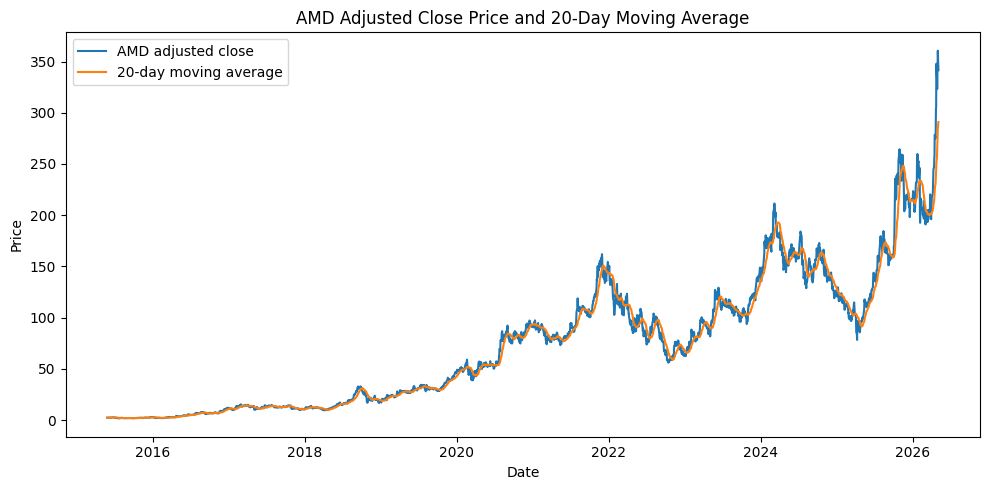

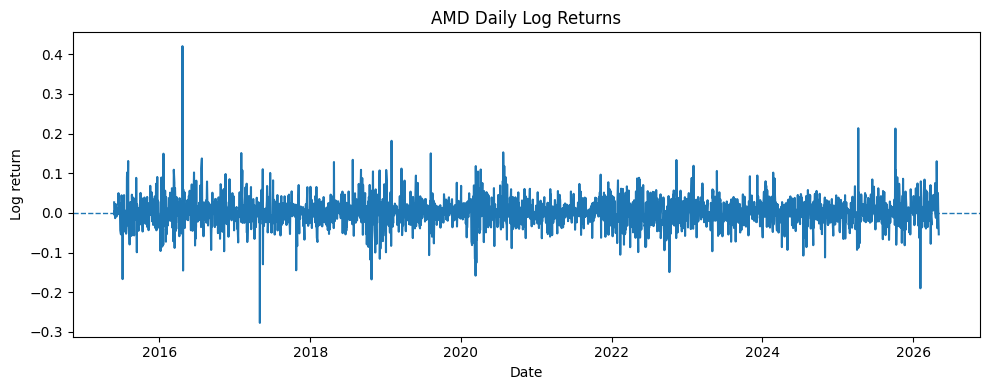

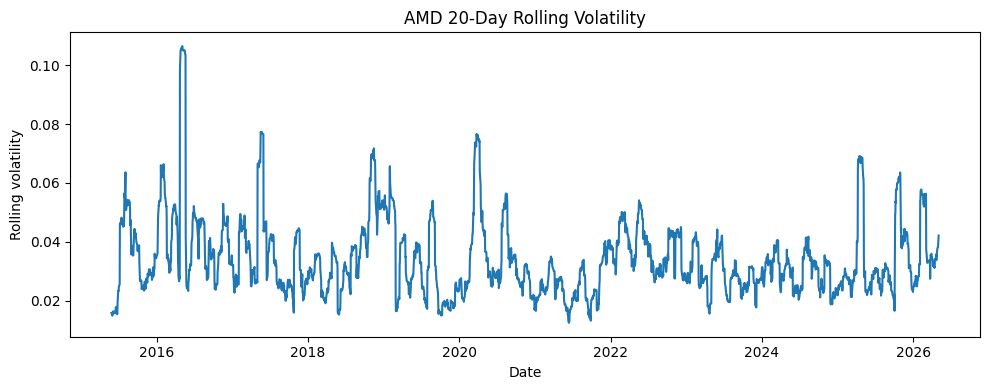

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Price'], label='AMD adjusted close')
plt.plot(df['Date'], df['ma_20'], label='20-day moving average')
plt.title('AMD Adjusted Close Price and 20-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.savefig('price_ma.png', dpi=200)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['log_return'])
plt.axhline(0, linestyle='--', linewidth=1)
plt.title('AMD Daily Log Returns')
plt.xlabel('Date')
plt.ylabel('Log return')
plt.tight_layout()
plt.savefig('log_returns.png', dpi=200)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['volatility_20'])
plt.title('AMD 20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Rolling volatility')
plt.tight_layout()
plt.savefig('rolling_volatility.png', dpi=200)
plt.show()

## 4. Train/validation/test split

This uses random stratified splitting:

- 60% training
- 20% validation
- 20% test

The validation set is used for model selection and hyperparameter tuning. The test set is saved until the end.

In [5]:
X_trainval, X_test, y_trainval, y_test, yreg_trainval, yreg_test, idx_trainval, idx_test = train_test_split(
    X, y, y_reg, df.index, test_size=0.20, random_state=0, stratify=y
)

X_train, X_val, y_train, y_val, yreg_train, yreg_val, idx_train, idx_val = train_test_split(
    X_trainval, y_trainval, yreg_trainval, idx_trainval, test_size=0.25, random_state=0, stratify=y_trainval
)

print('Train size:', X_train.shape)
print('Validation size:', X_val.shape)
print('Test size:', X_test.shape)
print('\nClass balance:')
print(pd.DataFrame({
    'train': y_train.value_counts(normalize=True),
    'val': y_val.value_counts(normalize=True),
    'test': y_test.value_counts(normalize=True)
}))

Train size: (1650, 21)
Validation size: (550, 21)
Test size: (551, 21)

Class balance:
                     train       val      test
target_direction                              
1                 0.510909  0.510909  0.509982
0                 0.489091  0.489091  0.490018


## 5. Normalization / whitening idea

We standardize features using the training set only. This avoids leakage from validation/test data.

Standardization is not full whitening, but it is the first step: every feature is shifted to mean zero and scaled to standard deviation one.

In [6]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
X_all_s = scaler.transform(X)

## 6. Probability and baseline model

The simplest probabilistic baseline is the majority-class classifier. If the market goes up slightly more often than down in the training set, this model always predicts up.

In [7]:
majority_class = int(y_train.mode()[0])
y_pred_base = np.full_like(y_test, majority_class)
baseline_acc = accuracy_score(y_test, y_pred_base)
print('Majority class:', majority_class)
print('Baseline test accuracy:', baseline_acc)

Majority class: 1
Baseline test accuracy: 0.5099818511796733


## 7. Linear regression and regularization

Even though the main target is classification, I include linear regression because it was a major course topic. Here we predict the next-day **log return** as a continuous variable.

We compare:

- ordinary least squares linear regression
- ridge regression, which uses an \(L^2\) penalty
- lasso regression, which uses an \(L^1\) penalty and can perform feature selection

In [27]:
reg_models = {
    'OLS Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1e-4, max_iter=10000)
}

reg_rows = []
for name, model in reg_models.items():
    model.fit(X_train_s, yreg_train)
    pred_val = model.predict(X_val_s)
    pred_test = model.predict(X_test_s)
    reg_rows.append({
        'Model': name,
        'Validation MSE': mean_squared_error(yreg_val, pred_val),
        'Test MSE': mean_squared_error(yreg_test, pred_test),
        'Validation R2': r2_score(yreg_val, pred_val),
        'Test R2': r2_score(yreg_test, pred_test)
    })

reg_results = pd.DataFrame(reg_rows)
reg_results

,Model,Validation MSE,Test MSE,Validation R2,Test R2
0,OLS Linear Regression,0.001557,0.001049,-0.006641,-0.014916
1,Ridge Regression,0.001560,0.001043,-0.008917,-0.008315
2,Lasso Regression,0.001558,0.001036,-0.007851,-0.002025


## 8. Logistic regression and hyperparameter validation

In [9]:
logit_grid = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('logit', LogisticRegression(max_iter=5000, solver='liblinear'))
    ]),
    param_grid={
        'logit__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'logit__penalty': ['l1', 'l2']
    },
    scoring='accuracy',
    cv=5
)
logit_grid.fit(X_trainval, y_trainval)

best_logit = logit_grid.best_estimator_
y_pred_logit = best_logit.predict(X_test)
y_prob_logit = best_logit.predict_proba(X_test)[:, 1]

print('Best logistic parameters:', logit_grid.best_params_)
print('Logistic test accuracy:', accuracy_score(y_test, y_pred_logit))
print('Logistic ROC AUC:', roc_auc_score(y_test, y_prob_logit))

c:\Users\Sally\miniconda3\envs\ml4p\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Sally\miniconda3\envs\ml4p\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Sally\miniconda3\envs\ml4p\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf in

Best logistic parameters: {'logit__C': 10, 'logit__penalty': 'l2'}
Logistic test accuracy: 0.5063520871143375
Logistic ROC AUC: 0.5235270858046659


c:\Users\Sally\miniconda3\envs\ml4p\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Sally\miniconda3\envs\ml4p\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Sally\miniconda3\envs\ml4p\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avo

## 9. Feature selection 

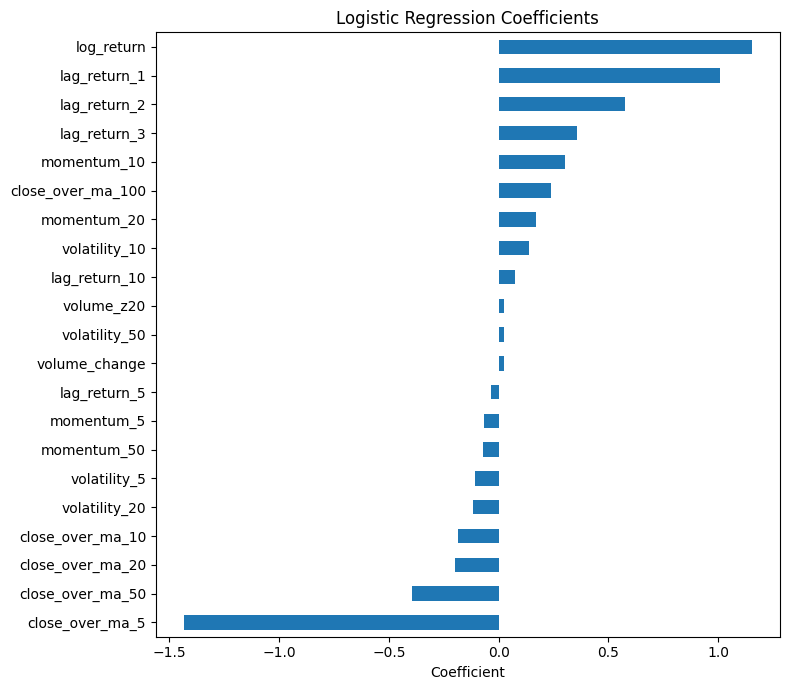

,coefficient
close_over_ma_5,-1.432741
close_over_ma_50,-0.394664
close_over_ma_20,-0.197779
close_over_ma_10,-0.186097
volatility_20,-0.117715
volatility_5,-0.106050
momentum_50,-0.072395
momentum_5,-0.067114
lag_return_5,-0.036371
volume_change,0.022275


In [10]:
logit_model = best_logit.named_steps['logit']
coef = pd.Series(logit_model.coef_[0], index=feature_cols).sort_values()

plt.figure(figsize=(8, 7))
coef.plot(kind='barh')
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig('logistic_coefficients.png', dpi=200)
plt.show()

coef.to_frame('coefficient')

## 10. Random forest as a nonlinear classical baseline


Random forest test accuracy: 0.47005444646098005
Random forest ROC AUC: 0.46558587056807704


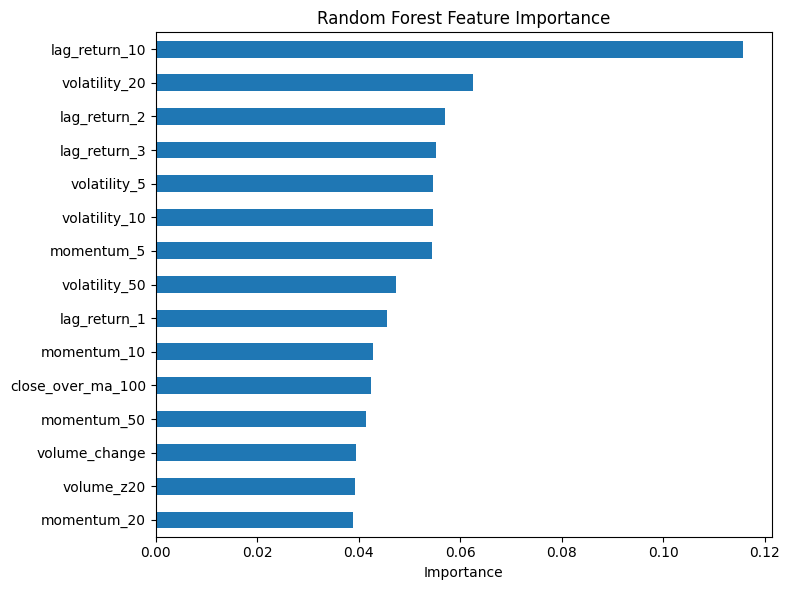

In [11]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=20,
    random_state=0,
    class_weight='balanced_subsample'
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('Random forest test accuracy:', accuracy_score(y_test, y_pred_rf))
print('Random forest ROC AUC:', roc_auc_score(y_test, y_prob_rf))

rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
rf_importance.head(15).sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=200)
plt.show()

## 11. SVD from linear algebra


In [12]:
# Manual SVD on the standardized full feature matrix
X_centered = X_all_s - X_all_s.mean(axis=0)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

explained_variance = (S**2) / (len(X_centered) - 1)
explained_ratio_svd = explained_variance / explained_variance.sum()

svd_table = pd.DataFrame({
    'Component': np.arange(1, len(S) + 1),
    'Singular value': S,
    'Explained variance ratio': explained_ratio_svd,
    'Cumulative explained variance': np.cumsum(explained_ratio_svd)
})
svd_table.head(10)

,Component,Singular value,Explained variance ratio,Cumulative explained variance
0,1,135.577060,0.326946,0.326946
1,2,87.313748,0.135603,0.462549
2,3,74.223462,0.097991,0.560540
3,4,64.300158,0.073541,0.634081
4,5,56.424674,0.056629,0.690711
5,6,54.539999,0.052910,0.743620
6,7,52.196649,0.048461,0.792081
7,8,51.150104,0.046537,0.838618
8,9,49.531340,0.043638,0.882256
9,10,43.841252,0.034188,0.916443


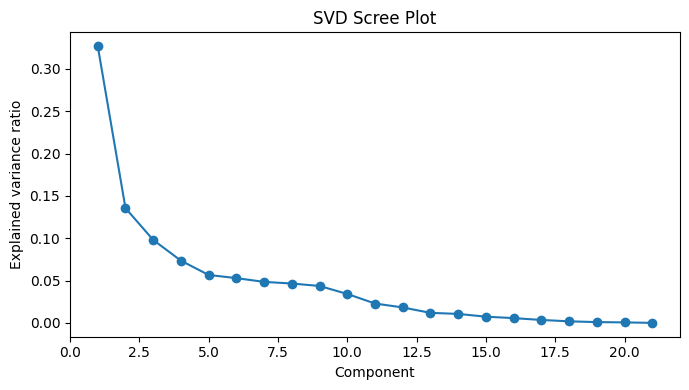

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(S)+1), explained_ratio_svd, marker='o')
plt.title('SVD Scree Plot')
plt.xlabel('Component')
plt.ylabel('Explained variance ratio')
plt.tight_layout()
plt.savefig('svd_scree_plot.png', dpi=200)
plt.show()

## 12. PCA visualization


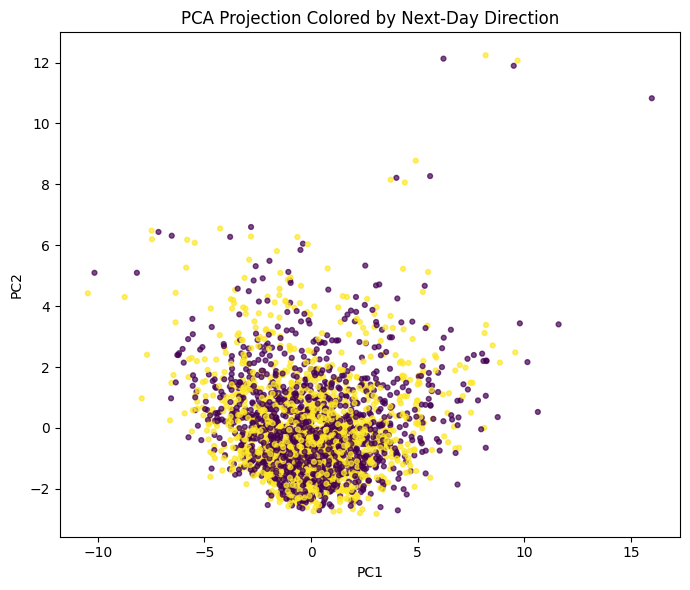

PCA explained variance ratios: [0.32694637 0.13560302]


In [14]:
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_all_s)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'target_direction': y.values,
    'next_log_return': y_reg.values,
    'volatility_20': df['volatility_20'].values,
    'momentum_20': df['momentum_20'].values,
    'Date': df['Date'].values
})

plt.figure(figsize=(7, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['target_direction'], s=12, alpha=0.7)
plt.title('PCA Projection Colored by Next-Day Direction')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('pca_direction.png', dpi=200)
plt.show()

print('PCA explained variance ratios:', pca.explained_variance_ratio_)

## 13. Whitening

Whitening rescales principal components so that each transformed component has unit variance. This is related to the course discussion of whitening data.

In [15]:
pca_white = PCA(n_components=min(10, X_all_s.shape[1]), whiten=True, random_state=0)
X_white = pca_white.fit_transform(X_all_s)
print('Variance of first whitened components:')
print(np.var(X_white[:, :5], axis=0))

Variance of first whitened components:
[0.9996365 0.9996365 0.9996365 0.9996365 0.9996365]


## 14. K-means clustering: market regimes



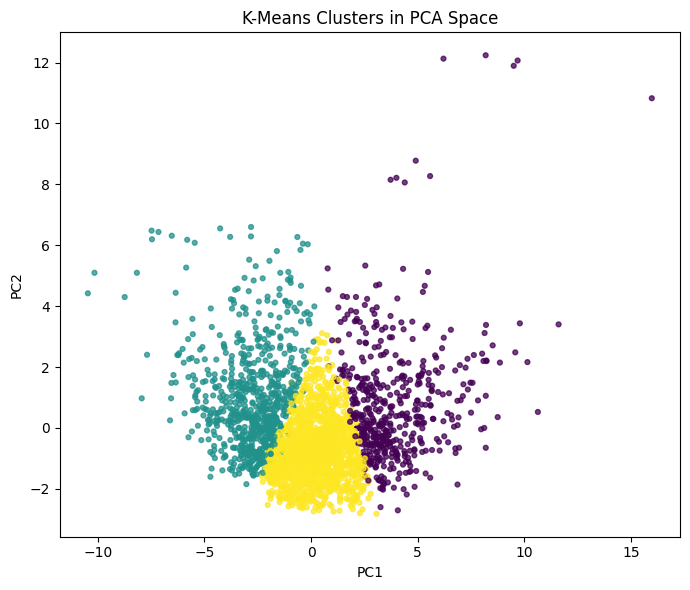

,cluster,mean_next_day_return,mean_volatility_20,mean_momentum_20,fraction_next_day_up,count
0,0,0.001848,0.041619,0.267176,0.497951,488
1,1,0.001897,0.039671,-0.104200,0.526667,750
2,2,0.001801,0.029228,0.053788,0.506940,1513


In [28]:
kmeans = KMeans(n_clusters=3, n_init=20, random_state=0)
clusters = kmeans.fit_predict(X_all_s)
pca_df['cluster'] = clusters

plt.figure(figsize=(7, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['cluster'], s=12, alpha=0.75)
plt.title('K-Means Clusters in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('kmeans_pca.png', dpi=200)
plt.show()

cluster_stats = pca_df.groupby('cluster').agg(
    mean_next_day_return=('next_log_return', 'mean'),
    mean_volatility_20=('volatility_20', 'mean'),
    mean_momentum_20=('momentum_20', 'mean'),
    fraction_next_day_up=('target_direction', 'mean'),
    count=('target_direction', 'size')
).reset_index()
cluster_stats

## 15. KDE-style density visualization


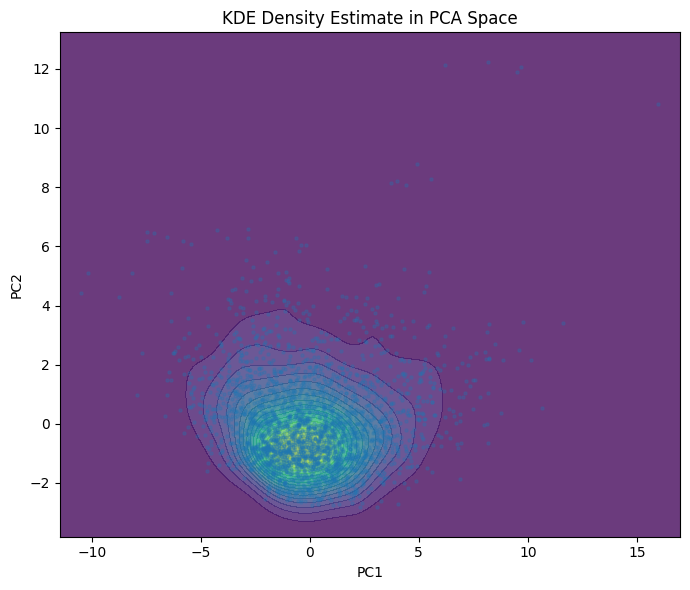

In [29]:
xy = X_pca[:, :2]
kde = KernelDensity(kernel='gaussian', bandwidth=0.6)
kde.fit(xy)

x_min, x_max = xy[:,0].min() - 1, xy[:,0].max() + 1
y_min, y_max = xy[:,1].min() - 1, xy[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 120), np.linspace(y_min, y_max, 120))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = np.exp(kde.score_samples(grid)).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, zz, levels=20, alpha=0.8)
plt.scatter(xy[:,0], xy[:,1], s=5, alpha=0.25)
plt.title('KDE Density Estimate in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('kde_pca_density.png', dpi=200)
plt.show()

## 16. PyTorch MLP

This section covers neural networks, gradients, mini-batches, stochastic optimization, and Adam.

The validation set is used to choose the best epoch. This is important because training loss can keep decreasing even when validation performance stops improving.

In [30]:
class MLP(nn.Module):
    def __init__(self, n_features, hidden=32, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

def make_loader(X_np, y_ser, batch_size=64, shuffle=True):
    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(np.asarray(y_ser), dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_s, y_train, batch_size=64, shuffle=True)
val_X_t = torch.tensor(X_val_s, dtype=torch.float32)
val_y_np = np.asarray(y_val)
test_X_t = torch.tensor(X_test_s, dtype=torch.float32)

model = MLP(n_features=X_train_s.shape[1], hidden=32, dropout=0.1)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

history = []
best_val_acc = -np.inf
best_state = None
best_epoch = None

for epoch in range(1, 301):
    model.train()
    losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_logits = model(val_X_t)
        val_prob = torch.sigmoid(val_logits).numpy()
        val_pred = (val_prob >= 0.5).astype(int)
        val_acc = accuracy_score(val_y_np, val_pred)
        val_loss = criterion(val_logits, torch.tensor(val_y_np, dtype=torch.float32)).item()

    history.append({'epoch': epoch, 'train_loss': np.mean(losses), 'val_loss': val_loss, 'val_acc': val_acc})

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
print('Best validation epoch:', best_epoch)
print('Best validation accuracy:', best_val_acc)

Best validation epoch: 1
Best validation accuracy: 0.5436363636363636


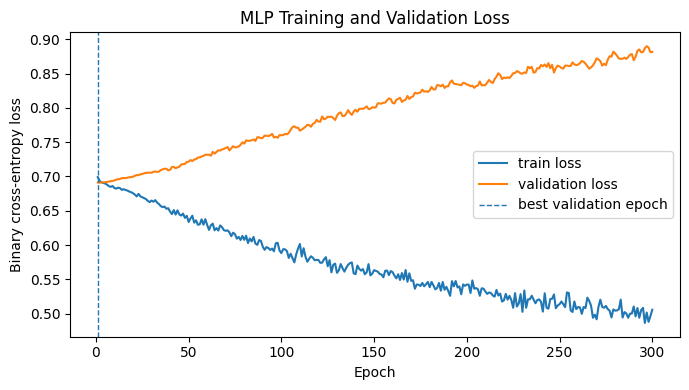

In [31]:
plt.figure(figsize=(7, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], label='train loss')
plt.plot(history_df['epoch'], history_df['val_loss'], label='validation loss')
plt.axvline(best_epoch, linestyle='--', linewidth=1, label='best validation epoch')
plt.title('MLP Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary cross-entropy loss')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_training_validation_loss.png', dpi=200)
plt.show()

## 17. Final supervised model comparison



In [20]:
model.eval()
with torch.no_grad():
    mlp_prob = torch.sigmoid(model(test_X_t)).numpy()
mlp_pred = (mlp_prob >= 0.5).astype(int)

results = pd.DataFrame([
    {'Model': 'Majority baseline', 'Test Accuracy': baseline_acc, 'ROC AUC': np.nan},
    {'Model': 'Logistic regression', 'Test Accuracy': accuracy_score(y_test, y_pred_logit), 'ROC AUC': roc_auc_score(y_test, y_prob_logit)},
    {'Model': 'Random forest', 'Test Accuracy': accuracy_score(y_test, y_pred_rf), 'ROC AUC': roc_auc_score(y_test, y_prob_rf)},
    {'Model': 'PyTorch MLP', 'Test Accuracy': accuracy_score(y_test, mlp_pred), 'ROC AUC': roc_auc_score(y_test, mlp_prob)},
])
results

,Model,Test Accuracy,ROC AUC
0,Majority baseline,0.509982,NaN
1,Logistic regression,0.506352,0.523527
2,Random forest,0.470054,0.465586
3,PyTorch MLP,0.513612,0.514960


In [21]:
cm = confusion_matrix(y_test, mlp_pred)
cm_df = pd.DataFrame(cm, index=['True Down', 'True Up'], columns=['Predicted Down', 'Predicted Up'])
cm_df

,Predicted Down,Predicted Up
True Down,114,156
True Up,112,169


              precision    recall  f1-score   support

        Down       0.50      0.42      0.46       270
          Up       0.52      0.60      0.56       281

    accuracy                           0.51       551
   macro avg       0.51      0.51      0.51       551
weighted avg       0.51      0.51      0.51       551



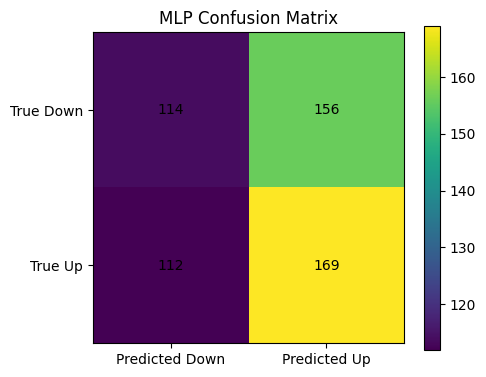

In [22]:
print(classification_report(y_test, mlp_pred, target_names=['Down', 'Up']))

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title('MLP Confusion Matrix')
plt.xticks([0, 1], ['Predicted Down', 'Predicted Up'])
plt.yticks([0, 1], ['True Down', 'True Up'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar()
plt.tight_layout()
plt.savefig('mlp_confusion_matrix.png', dpi=200)
plt.show()

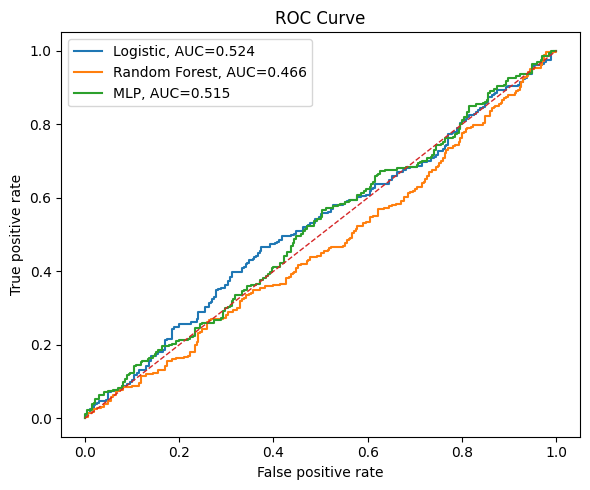

In [23]:
plt.figure(figsize=(6, 5))
for name, prob in [('Logistic', y_prob_logit), ('Random Forest', y_prob_rf), ('MLP', mlp_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name}, AUC={auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.title('ROC Curve')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=200)
plt.show()

## 18. Backtesting diagnostic



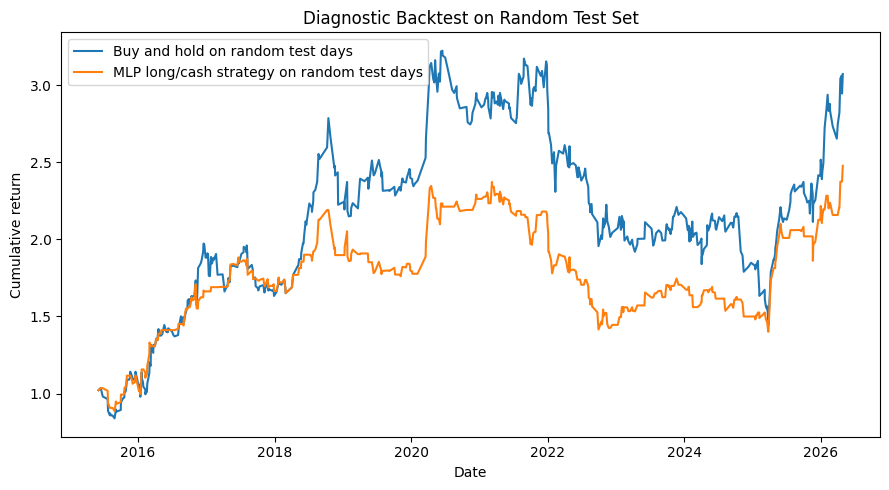

In [24]:
# Attach predictions to the test rows and sort by actual date for plotting cumulative returns.
test_df = df.loc[idx_test].copy()
test_df['mlp_prob'] = mlp_prob
test_df['mlp_pred'] = mlp_pred
test_df = test_df.sort_values('Date')

test_df['position'] = test_df['mlp_pred']
test_df['strategy_log_return'] = test_df['position'] * test_df['next_log_return']
test_df['buy_hold_cum'] = np.exp(test_df['next_log_return'].cumsum())
test_df['strategy_cum'] = np.exp(test_df['strategy_log_return'].cumsum())

plt.figure(figsize=(9, 5))
plt.plot(test_df['Date'], test_df['buy_hold_cum'], label='Buy and hold on random test days')
plt.plot(test_df['Date'], test_df['strategy_cum'], label='MLP long/cash strategy on random test days')
plt.title('Diagnostic Backtest on Random Test Set')
plt.xlabel('Date')
plt.ylabel('Cumulative return')
plt.legend()
plt.tight_layout()
plt.savefig('backtest_random_test.png', dpi=200)
plt.show()

In [25]:
print('TABLE 1: Supervised model comparison')
display(results)

print('\nTABLE 2: MLP confusion matrix')
display(cm_df)

print('\nTABLE 3: K-means cluster statistics')
display(cluster_stats)

print('\nTABLE 4: Regression comparison')
display(reg_results)

print('\nSVD table')
display(svd_table.head(10))

TABLE 1: Supervised model comparison


,Model,Test Accuracy,ROC AUC
0,Majority baseline,0.509982,NaN
1,Logistic regression,0.506352,0.523527
2,Random forest,0.470054,0.465586
3,PyTorch MLP,0.513612,0.514960



TABLE 2: MLP confusion matrix


,Predicted Down,Predicted Up
True Down,114,156
True Up,112,169



TABLE 3: K-means cluster statistics


,cluster,mean_next_day_return,mean_volatility_20,mean_momentum_20,fraction_next_day_up,count
0,0,0.001848,0.041619,0.267176,0.497951,488
1,1,0.001897,0.039671,-0.104200,0.526667,750
2,2,0.001801,0.029228,0.053788,0.506940,1513



TABLE 4: Regression comparison


,Model,Validation MSE,Test MSE,Validation R2,Test R2
0,OLS Linear Regression,0.001557,0.001049,-0.006641,-0.014916
1,Ridge Regression,0.001560,0.001043,-0.008917,-0.008315
2,Lasso Regression,0.001558,0.001036,-0.007851,-0.002025



SVD table


,Component,Singular value,Explained variance ratio,Cumulative explained variance
0,1,135.577060,0.326946,0.326946
1,2,87.313748,0.135603,0.462549
2,3,74.223462,0.097991,0.560540
3,4,64.300158,0.073541,0.634081
4,5,56.424674,0.056629,0.690711
5,6,54.539999,0.052910,0.743620
6,7,52.196649,0.048461,0.792081
7,8,51.150104,0.046537,0.838618
8,9,49.531340,0.043638,0.882256
9,10,43.841252,0.034188,0.916443
